Saving uber.csv to uber (3).csv
   Unnamed: 0                            key  fare_amount  \
0    24238194    2015-05-07 19:52:06.0000003          7.5   
1    27835199    2009-07-17 20:04:56.0000002          7.7   
2    44984355   2009-08-24 21:45:00.00000061         12.9   
3    25894730    2009-06-26 08:22:21.0000001          5.3   
4    17610152  2014-08-28 17:47:00.000000188         16.0   

           pickup_datetime  pickup_longitude  pickup_latitude  \
0  2015-05-07 19:52:06 UTC        -73.999817        40.738354   
1  2009-07-17 20:04:56 UTC        -73.994355        40.728225   
2  2009-08-24 21:45:00 UTC        -74.005043        40.740770   
3  2009-06-26 08:22:21 UTC        -73.976124        40.790844   
4  2014-08-28 17:47:00 UTC        -73.925023        40.744085   

   dropoff_longitude  dropoff_latitude  passenger_count  
0         -73.999512         40.723217                1  
1         -73.994710         40.750325                1  
2         -73.962565         40.7726

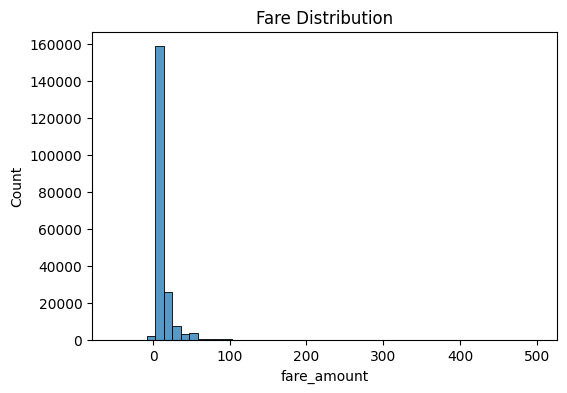

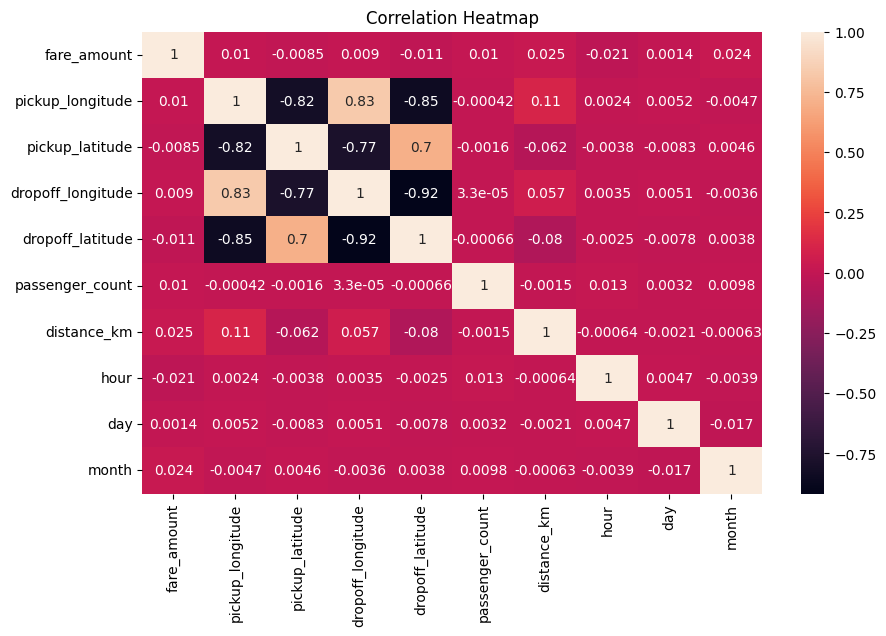

Linear Regression RMSE: 10.19121135867592
Linear Regression MAE: 6.063823075581229
Random Forest RMSE: 5.559710371041881
Random Forest MAE: 2.274789233001984
XGBoost RMSE: 5.586779123944572
XGBoost MAE: 2.229776161520183
               Model       RMSE       MAE
0  Linear Regression  10.191211  6.063823
1      Random Forest   5.559710  2.274789
2            XGBoost   5.586779  2.229776


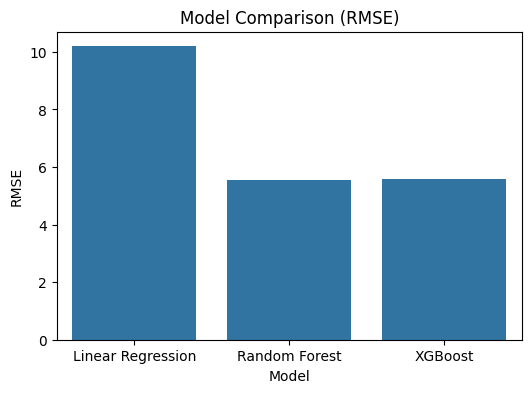

In [59]:
# ==============================
# 1. Import Libraries
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


# ==============================
# 2. Upload Dataset
# ==============================

from google.colab import files
uploaded = files.upload()


# ==============================
# 3. Load Dataset
# ==============================

df = pd.read_csv("uber.csv")

print(df.head())
print(df.info())


# ==============================
# 4. Data Cleaning
# ==============================

df = df.drop(['Unnamed: 0','key'], axis=1, errors='ignore')

df = df.dropna()


# ==============================
# 5. Feature Engineering
# Haversine Distance
# ==============================

def haversine_distance(lat1, lon1, lat2, lon2):

    R = 6371

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2*np.arcsin(np.sqrt(a))

    return R*c


df['distance_km'] = haversine_distance(
    df['pickup_latitude'],
    df['pickup_longitude'],
    df['dropoff_latitude'],
    df['dropoff_longitude']
)


# ==============================
# 6. Convert Datetime
# ==============================

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.day
df['month'] = df['pickup_datetime'].dt.month

df = df.drop('pickup_datetime', axis=1)


# ==============================
# 7. Exploratory Data Analysis
# ==============================

plt.figure(figsize=(6,4))
sns.histplot(df['fare_amount'], bins=50)
plt.title("Fare Distribution")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()


# ==============================
# 8. Prepare Data
# ==============================

X = df.drop('fare_amount', axis=1)
y = df['fare_amount']


# ==============================
# 9. Train Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ==============================
# 10. Linear Regression
# ==============================

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression MAE:", lr_mae)


# ==============================
# 11. Random Forest
# ==============================

rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest MAE:", rf_mae)


# ==============================
# 12. XGBoost
# ==============================

xgb = XGBRegressor(n_estimators=100)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae = mean_absolute_error(y_test, xgb_pred)

print("XGBoost RMSE:", xgb_rmse)
print("XGBoost MAE:", xgb_mae)


# ==============================
# 13. Model Comparison
# ==============================

results = pd.DataFrame({

    'Model': ['Linear Regression','Random Forest','XGBoost'],
    'RMSE': [lr_rmse, rf_rmse, xgb_rmse],
    'MAE': [lr_mae, rf_mae, xgb_mae]

})

print(results)


# ==============================
# 14. Visualization
# ==============================

plt.figure(figsize=(6,4))

sns.barplot(x='Model', y='RMSE', data=results)

plt.title("Model Comparison (RMSE)")

plt.show()